In [1]:
import numpy as np 
import pandas as pd 

In [2]:
df = pd.read_csv("BankChurners.csv")

CLIENTNUM: Unique identifier for each customer. (Integer)

Attrition_Flag: Flag indicating whether or not the customer has churned out. (Boolean)

Customer_Age: Age of customer. (Integer)

Gender: Gender of customer. (String)

Dependent_count: Number of dependents that customer has. (Integer)

Education_Level: Education level of customer. (String)

Marital_Status: Marital status of customer. (String)

Income_Category: Income category of customer. (String)

Card_Category: Type of card held by customer. (String)

Months_on_book: How long customer has been on the books. (Integer)

Total_Relationship_Count: Total number of relationships customer has with the credit card provider. (Integer)

Months_Inactive_12_mon: Number of months customer has been inactive in the last twelve months. (Integer)

Contacts_Count_12_mon: Number of contacts customer has had in the last twelve months. (Integer)

Credit_Limit: Credit limit of customer. (Integer)

Total_Revolving_Bal: Total revolving balance of customer. (Integer)

Avg_Open_To_Buy: Average open to buy ratio of customer. (Integer)

Total_Amt_Chng_Q4_Q1: Total amount changed from quarter 4 to quarter 1. (Integer)

Total_Trans_Amt: Total transaction amount. (Integer)

Total_Trans_Ct: Total transaction count. (Integer)

Total_Ct_Chng_Q4_Q1: Total count changed from quarter 4 to quarter 1. (Integer)

Avg_Utilization_Ratio: Average utilization ratio of customer. (Integer)

Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1: Naive Bayes classifier for predicting whether or not someone will churn based on characteristics such

In [3]:
df.head()

,CLIENTNUM,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,...,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio,Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1,Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2
0,768805383,Existing Customer,45,M,3,High School,Married,$60K - $80K,Blue,39,...,12691.0,777,11914.0,1.335,1144,42,1.625,0.061,0.000093,0.99991
1,818770008,Existing Customer,49,F,5,Graduate,Single,Less than $40K,Blue,44,...,8256.0,864,7392.0,1.541,1291,33,3.714,0.105,0.000057,0.99994
2,713982108,Existing Customer,51,M,3,Graduate,Married,$80K - $120K,Blue,36,...,3418.0,0,3418.0,2.594,1887,20,2.333,0.000,0.000021,0.99998
3,769911858,Existing Customer,40,F,4,High School,Unknown,Less than $40K,Blue,34,...,3313.0,2517,796.0,1.405,1171,20,2.333,0.760,0.000134,0.99987
4,709106358,Existing Customer,40,M,3,Uneducated,Married,$60K - $80K,Blue,21,...,4716.0,0,4716.0,2.175,816,28,2.500,0.000,0.000022,0.99998


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10127 entries, 0 to 10126
Data columns (total 23 columns):
 #   Column                                                                                                                              Non-Null Count  Dtype  
---  ------                                                                                                                              --------------  -----  
 0   CLIENTNUM                                                                                                                           10127 non-null  int64  
 1   Attrition_Flag                                                                                                                      10127 non-null  object 
 2   Customer_Age                                                                                                                        10127 non-null  int64  
 3   Gender                                                                           

In [5]:
df.columns

Index(['CLIENTNUM', 'Attrition_Flag', 'Customer_Age', 'Gender',
       'Dependent_count', 'Education_Level', 'Marital_Status',
       'Income_Category', 'Card_Category', 'Months_on_book',
       'Total_Relationship_Count', 'Months_Inactive_12_mon',
       'Contacts_Count_12_mon', 'Credit_Limit', 'Total_Revolving_Bal',
       'Avg_Open_To_Buy', 'Total_Amt_Chng_Q4_Q1', 'Total_Trans_Amt',
       'Total_Trans_Ct', 'Total_Ct_Chng_Q4_Q1', 'Avg_Utilization_Ratio',
       'Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1',
       'Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2'],
      dtype='object')

**Editing Datasets**

In [6]:
drop_cols = ['Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1',
       'Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2', 'CLIENTNUM']

In [7]:
df = df.drop(drop_cols, axis= 1)

In [8]:
df.head()

,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio
0,Existing Customer,45,M,3,High School,Married,$60K - $80K,Blue,39,5,1,3,12691.0,777,11914.0,1.335,1144,42,1.625,0.061
1,Existing Customer,49,F,5,Graduate,Single,Less than $40K,Blue,44,6,1,2,8256.0,864,7392.0,1.541,1291,33,3.714,0.105
2,Existing Customer,51,M,3,Graduate,Married,$80K - $120K,Blue,36,4,1,0,3418.0,0,3418.0,2.594,1887,20,2.333,0.000
3,Existing Customer,40,F,4,High School,Unknown,Less than $40K,Blue,34,3,4,1,3313.0,2517,796.0,1.405,1171,20,2.333,0.760
4,Existing Customer,40,M,3,Uneducated,Married,$60K - $80K,Blue,21,5,1,0,4716.0,0,4716.0,2.175,816,28,2.500,0.000


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10127 entries, 0 to 10126
Data columns (total 20 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Attrition_Flag            10127 non-null  object 
 1   Customer_Age              10127 non-null  int64  
 2   Gender                    10127 non-null  object 
 3   Dependent_count           10127 non-null  int64  
 4   Education_Level           10127 non-null  object 
 5   Marital_Status            10127 non-null  object 
 6   Income_Category           10127 non-null  object 
 7   Card_Category             10127 non-null  object 
 8   Months_on_book            10127 non-null  int64  
 9   Total_Relationship_Count  10127 non-null  int64  
 10  Months_Inactive_12_mon    10127 non-null  int64  
 11  Contacts_Count_12_mon     10127 non-null  int64  
 12  Credit_Limit              10127 non-null  float64
 13  Total_Revolving_Bal       10127 non-null  int64  
 14  Avg_Op

In [10]:
df.describe()

,Customer_Age,Dependent_count,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio
count,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000
mean,46.325960,2.346203,35.928409,3.812580,2.341167,2.455317,8631.953698,1162.814061,7469.139637,0.759941,4404.086304,64.858695,0.712222,0.274894
std,8.016814,1.298908,7.986416,1.554408,1.010622,1.106225,9088.776650,814.987335,9090.685324,0.219207,3397.129254,23.472570,0.238086,0.275691
min,26.000000,0.000000,13.000000,1.000000,0.000000,0.000000,1438.300000,0.000000,3.000000,0.000000,510.000000,10.000000,0.000000,0.000000
25%,41.000000,1.000000,31.000000,3.000000,2.000000,2.000000,2555.000000,359.000000,1324.500000,0.631000,2155.500000,45.000000,0.582000,0.023000
50%,46.000000,2.000000,36.000000,4.000000,2.000000,2.000000,4549.000000,1276.000000,3474.000000,0.736000,3899.000000,67.000000,0.702000,0.176000
75%,52.000000,3.000000,40.000000,5.000000,3.000000,3.000000,11067.500000,1784.000000,9859.000000,0.859000,4741.000000,81.000000,0.818000,0.503000
max,73.000000,5.000000,56.000000,6.000000,6.000000,6.000000,34516.000000,2517.000000,34516.000000,3.397000,18484.000000,139.000000,3.714000,0.999000


In [11]:
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

**EDA**

In [12]:
import math
def plot_all_histograms(df, title_prefix= ""):
    numeric_cols = df.select_dtypes(include= [np.number]).columns
    n_cols= 3
    n_rows= math.ceil(len(numeric_cols) / n_cols) #yukarı yuvarlama

    plt.figure(figsize= (4 * n_cols, 3 * n_rows))

    for i, col in enumerate(numeric_cols, 1):
        plt.subplot(n_rows, n_cols, i)
        sns.histplot(df[col], kde= True, bins= 30)
        plt.title(f"{title_prefix} {col}")
        plt.xlabel("")
        plt.ylabel("")
    plt.tight_layout()
    plt.show()

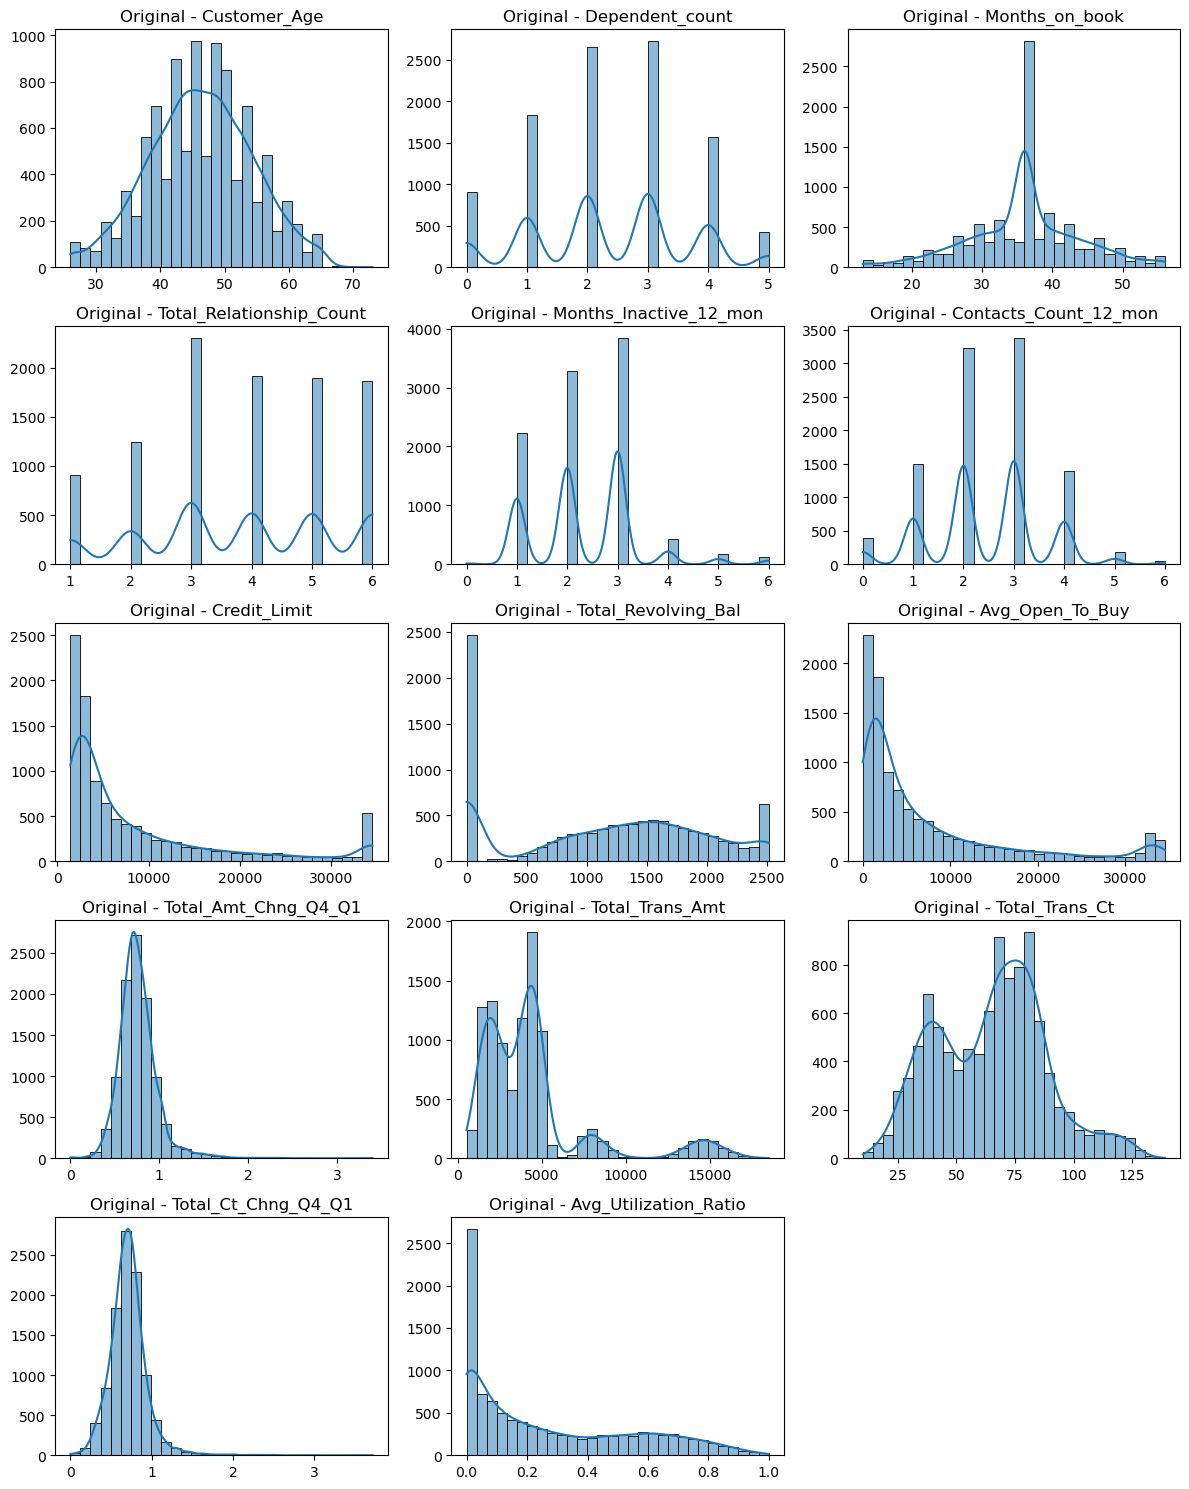

In [13]:
plot_all_histograms(df, title_prefix= "Original -")

In [14]:
numeric_col = ['Customer_Age', 'Months_on_book', 'Credit_Limit', 'Total_Trans_Amt', 'Total_Trans_Ct', 'Avg_Utilization_Ratio']

<Figure size 640x480 with 0 Axes>

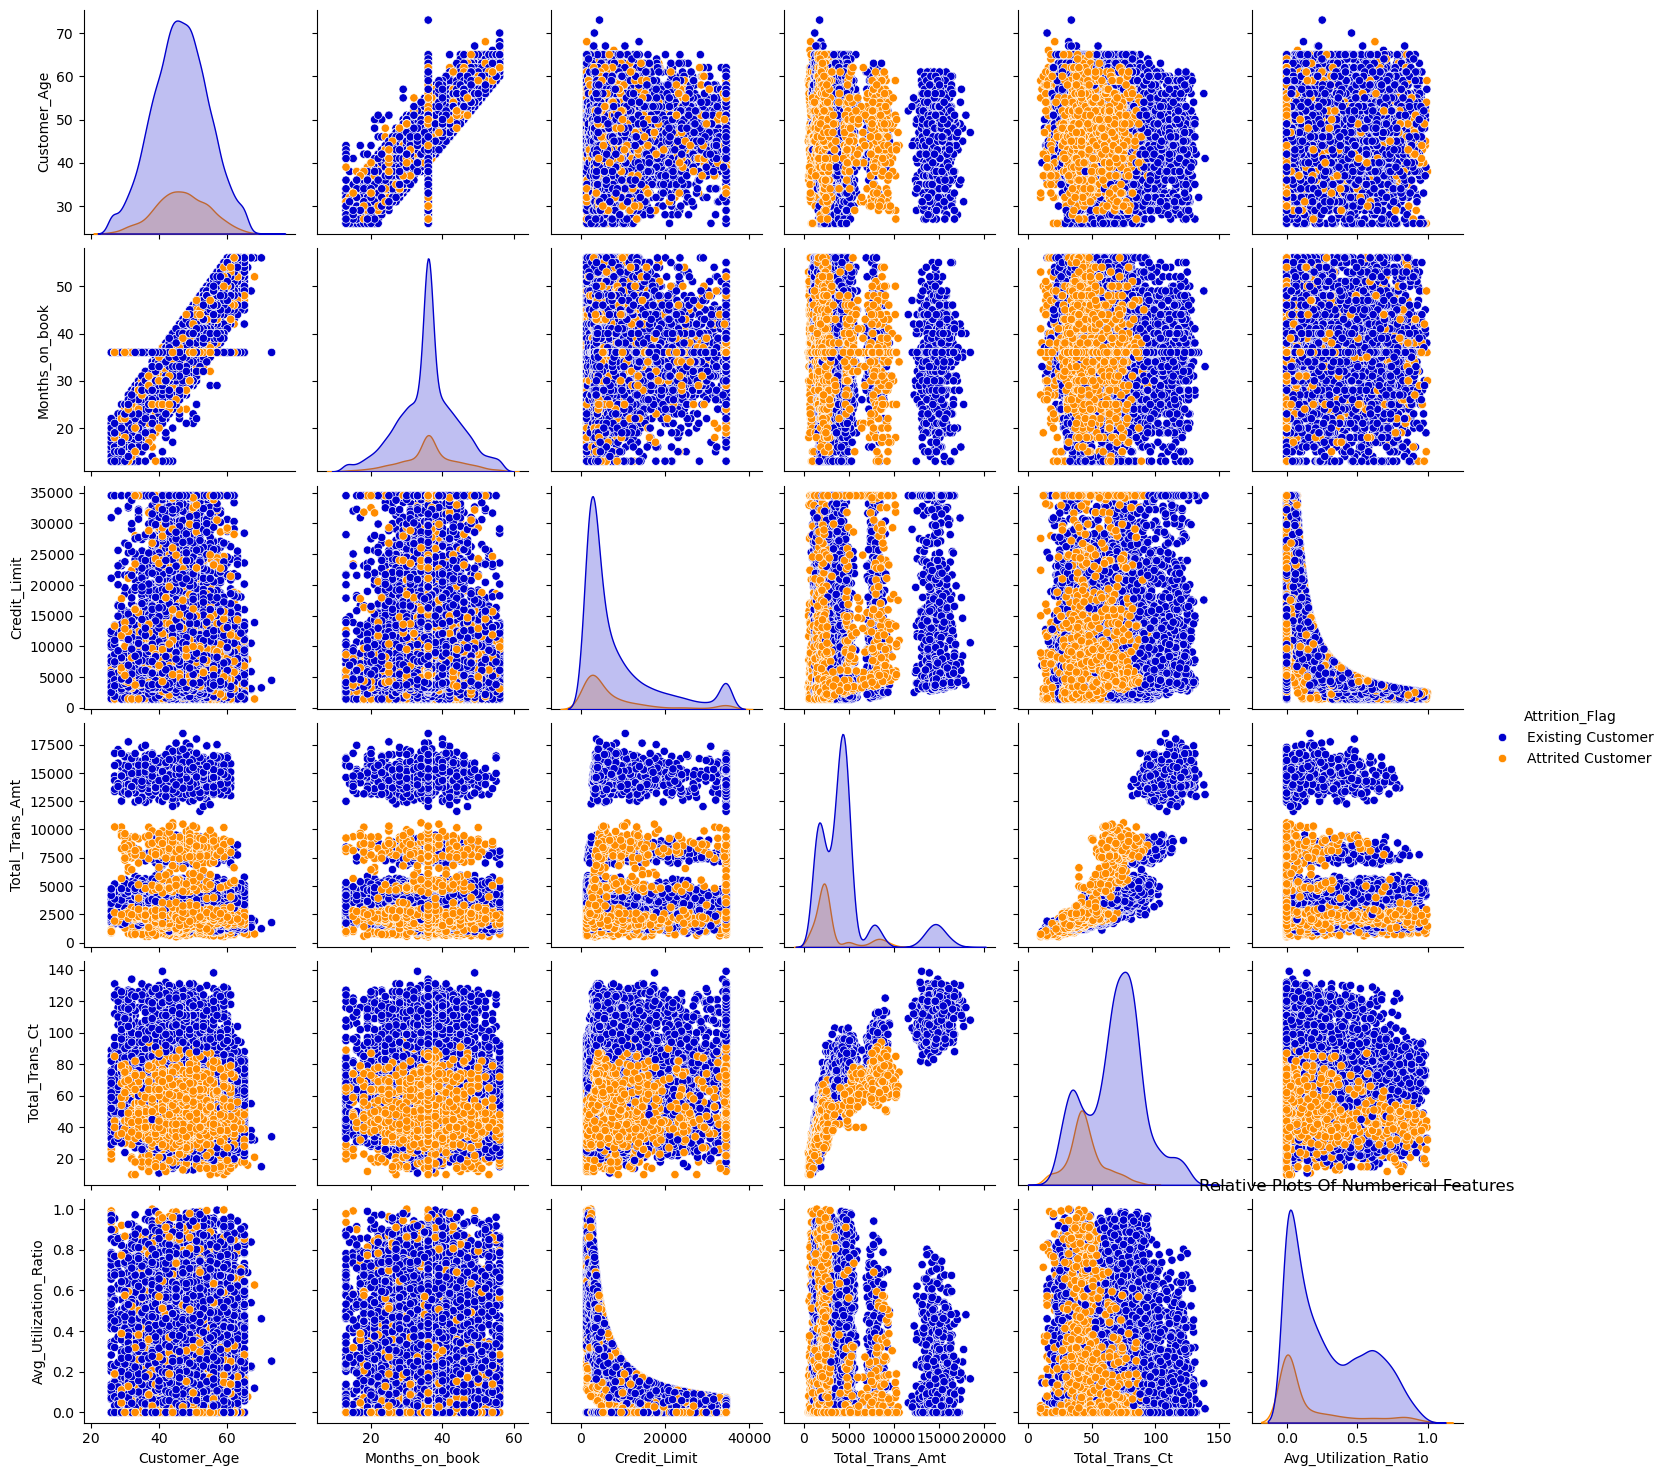

In [15]:
plt.figure();
sns.pairplot(df, vars= numeric_col , hue='Attrition_Flag', palette= (["mediumblue","darkorange"]));
plt.title('Relative Plots Of Numberical Features');
plt.show();

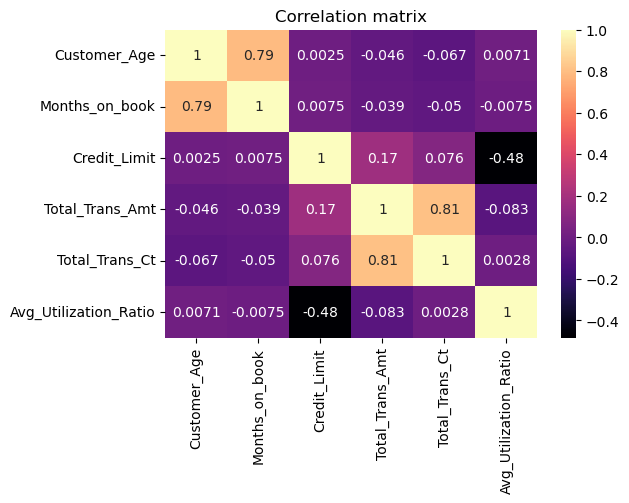

In [16]:
plt.figure(figsize = (6,4));
sns.heatmap(df[numeric_col].corr(), annot = True, cmap="magma");
plt.title('Correlation matrix');

In [17]:
categoric_cols = df.select_dtypes(include= ["category", "object"]).columns
for col in categoric_cols:
    print(df[col].value_counts(), "\n")

Attrition_Flag
Existing Customer    8500
Attrited Customer    1627
Name: count, dtype: int64 

Gender
F    5358
M    4769
Name: count, dtype: int64 

Education_Level
Graduate         3128
High School      2013
Unknown          1519
Uneducated       1487
College          1013
Post-Graduate     516
Doctorate         451
Name: count, dtype: int64 

Marital_Status
Married     4687
Single      3943
Unknown      749
Divorced     748
Name: count, dtype: int64 

Income_Category
Less than $40K    3561
$40K - $60K       1790
$80K - $120K      1535
$60K - $80K       1402
Unknown           1112
$120K +            727
Name: count, dtype: int64 

Card_Category
Blue        9436
Silver       555
Gold         116
Platinum      20
Name: count, dtype: int64 



In [18]:
#Binary Encoding

In [19]:
df["Attrition_Flag"] = df["Attrition_Flag"].map({"Existing Customer": 0, "Attrited Customer": 1})
df["Gender"] = df["Gender"].map({"F": 0, "M": 1})

In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10127 entries, 0 to 10126
Data columns (total 20 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Attrition_Flag            10127 non-null  int64  
 1   Customer_Age              10127 non-null  int64  
 2   Gender                    10127 non-null  int64  
 3   Dependent_count           10127 non-null  int64  
 4   Education_Level           10127 non-null  object 
 5   Marital_Status            10127 non-null  object 
 6   Income_Category           10127 non-null  object 
 7   Card_Category             10127 non-null  object 
 8   Months_on_book            10127 non-null  int64  
 9   Total_Relationship_Count  10127 non-null  int64  
 10  Months_Inactive_12_mon    10127 non-null  int64  
 11  Contacts_Count_12_mon     10127 non-null  int64  
 12  Credit_Limit              10127 non-null  float64
 13  Total_Revolving_Bal       10127 non-null  int64  
 14  Avg_Op

In [21]:
df.shape

(10127, 20)

In [22]:
#Independent - Dependent Features

In [23]:
X = df.drop("Attrition_Flag", axis= 1)
y = df["Attrition_Flag"]

In [24]:
from sklearn.model_selection import train_test_split

In [25]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size= 0.3, random_state= 15)

In [26]:
#Ordinal Encoding and One Hot Encoding

In [27]:
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer

In [28]:
ordinal_cols = ["Education_Level", "Income_Category", "Card_Category"]
onehot_cols = ["Marital_Status"]
preprocessor = ColumnTransformer(transformers= [
    ("Ordinal", OrdinalEncoder(), ordinal_cols),
    ("OneHot", OneHotEncoder(handle_unknown= "ignore"), onehot_cols),
], remainder= "passthrough")

X_train = preprocessor.fit_transform(X_train)
X_test = preprocessor.transform(X_test)

In [29]:
preprocessor.get_feature_names_out()

array(['Ordinal__Education_Level', 'Ordinal__Income_Category',
       'Ordinal__Card_Category', 'OneHot__Marital_Status_Divorced',
       'OneHot__Marital_Status_Married', 'OneHot__Marital_Status_Single',
       'OneHot__Marital_Status_Unknown', 'remainder__Customer_Age',
       'remainder__Gender', 'remainder__Dependent_count',
       'remainder__Months_on_book', 'remainder__Total_Relationship_Count',
       'remainder__Months_Inactive_12_mon',
       'remainder__Contacts_Count_12_mon', 'remainder__Credit_Limit',
       'remainder__Total_Revolving_Bal', 'remainder__Avg_Open_To_Buy',
       'remainder__Total_Amt_Chng_Q4_Q1', 'remainder__Total_Trans_Amt',
       'remainder__Total_Trans_Ct', 'remainder__Total_Ct_Chng_Q4_Q1',
       'remainder__Avg_Utilization_Ratio'], dtype=object)

In [30]:
X_train

array([[  6.   ,   5.   ,   0.   , ...,  85.   ,   0.771,   0.   ],
       [  5.   ,   2.   ,   0.   , ..., 112.   ,   0.672,   0.291],
       [  3.   ,   4.   ,   0.   , ...,  79.   ,   0.795,   0.504],
       ...,
       [  0.   ,   5.   ,   0.   , ...,  37.   ,   0.423,   0.   ],
       [  3.   ,   4.   ,   0.   , ...,  66.   ,   0.571,   0.683],
       [  1.   ,   1.   ,   0.   , ...,  56.   ,   0.806,   0.   ]],
      shape=(7088, 22))

In [31]:
#Yeo - Johnson Transformation

In [32]:
from sklearn.preprocessing import PowerTransformer

In [33]:
pt_X = PowerTransformer(method= "yeo-johnson")
X_train_transformed = pt_X.fit_transform(X_train)
X_test_transformed = pt_X.transform(X_test)

In [34]:
X_train_transformed_df = pd.DataFrame(X_train_transformed, columns= preprocessor.get_feature_names_out())

In [35]:
X_train_transformed_df

,Ordinal__Education_Level,Ordinal__Income_Category,Ordinal__Card_Category,OneHot__Marital_Status_Divorced,OneHot__Marital_Status_Married,OneHot__Marital_Status_Single,OneHot__Marital_Status_Unknown,remainder__Customer_Age,remainder__Gender,remainder__Dependent_count,...,remainder__Months_Inactive_12_mon,remainder__Contacts_Count_12_mon,remainder__Credit_Limit,remainder__Total_Revolving_Bal,remainder__Avg_Open_To_Buy,remainder__Total_Amt_Chng_Q4_Q1,remainder__Total_Trans_Amt,remainder__Total_Trans_Ct,remainder__Total_Ct_Chng_Q4_Q1,remainder__Avg_Utilization_Ratio
0,1.490441,1.494320,-0.266796,-0.285442,-0.931251,1.262334,-0.283994,-1.419583,-0.94534,-0.247227,...,-1.450995,-0.402282,-1.577583,-1.653704,-0.658388,0.359978,0.459533,0.861627,0.354943,-1.194538
1,1.024300,-0.621410,-0.266796,-0.285442,1.073824,-0.792183,-0.283994,0.952824,1.05782,-0.247227,...,0.714405,-1.313876,0.331691,0.803870,0.191741,-0.203104,1.986432,1.904954,-0.089387,0.375565
2,0.017380,0.754074,-0.266796,-0.285442,-0.931251,-0.792183,3.521202,-0.049923,-0.94534,1.977552,...,0.714405,0.496754,-1.652393,-0.037567,-1.207522,-0.108255,0.192479,0.620287,0.456413,1.004423
3,-0.539362,-1.240273,3.748353,-0.285442,1.073824,-0.792183,-0.283994,0.701672,-0.94534,-0.247227,...,0.714405,-0.402282,1.300225,-1.653704,1.310471,1.147123,0.447751,0.701174,0.311977,-1.194538
4,-0.539362,-1.240273,-0.266796,-0.285442,-0.931251,-0.792183,3.521202,-0.049923,1.05782,-1.035535,...,0.714405,-0.402282,-1.652393,0.113987,-1.397544,1.662962,-0.256900,-0.703143,2.432813,1.247574
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7083,-0.539362,-1.240273,-0.266796,-0.285442,1.073824,-0.792183,-0.283994,0.827211,-0.94534,-1.035535,...,0.714405,0.496754,-0.716302,1.098750,-2.028712,-0.930266,0.283473,0.208691,-0.037847,1.690250
7084,-0.539362,-1.240273,-0.266796,-0.285442,-0.931251,1.262334,-0.283994,1.834087,-0.94534,-1.869107,...,0.714405,2.269098,0.418217,0.045531,0.429196,-1.570966,0.210949,0.082684,-0.194201,-0.435668
7085,-1.866208,1.494320,-0.266796,-0.285442,1.073824,-0.792183,-0.283994,1.204267,-0.94534,-1.035535,...,1.513439,1.386567,-1.652393,-1.653704,-0.693027,0.582118,-0.668465,-1.215380,-1.432458,-1.194538
7086,0.017380,0.754074,-0.266796,-0.285442,-0.931251,1.262334,-0.283994,-1.171443,-0.94534,1.253151,...,-1.450995,-0.402282,-1.143870,0.474904,-1.291710,0.586525,0.431013,0.082684,-0.590841,1.362280


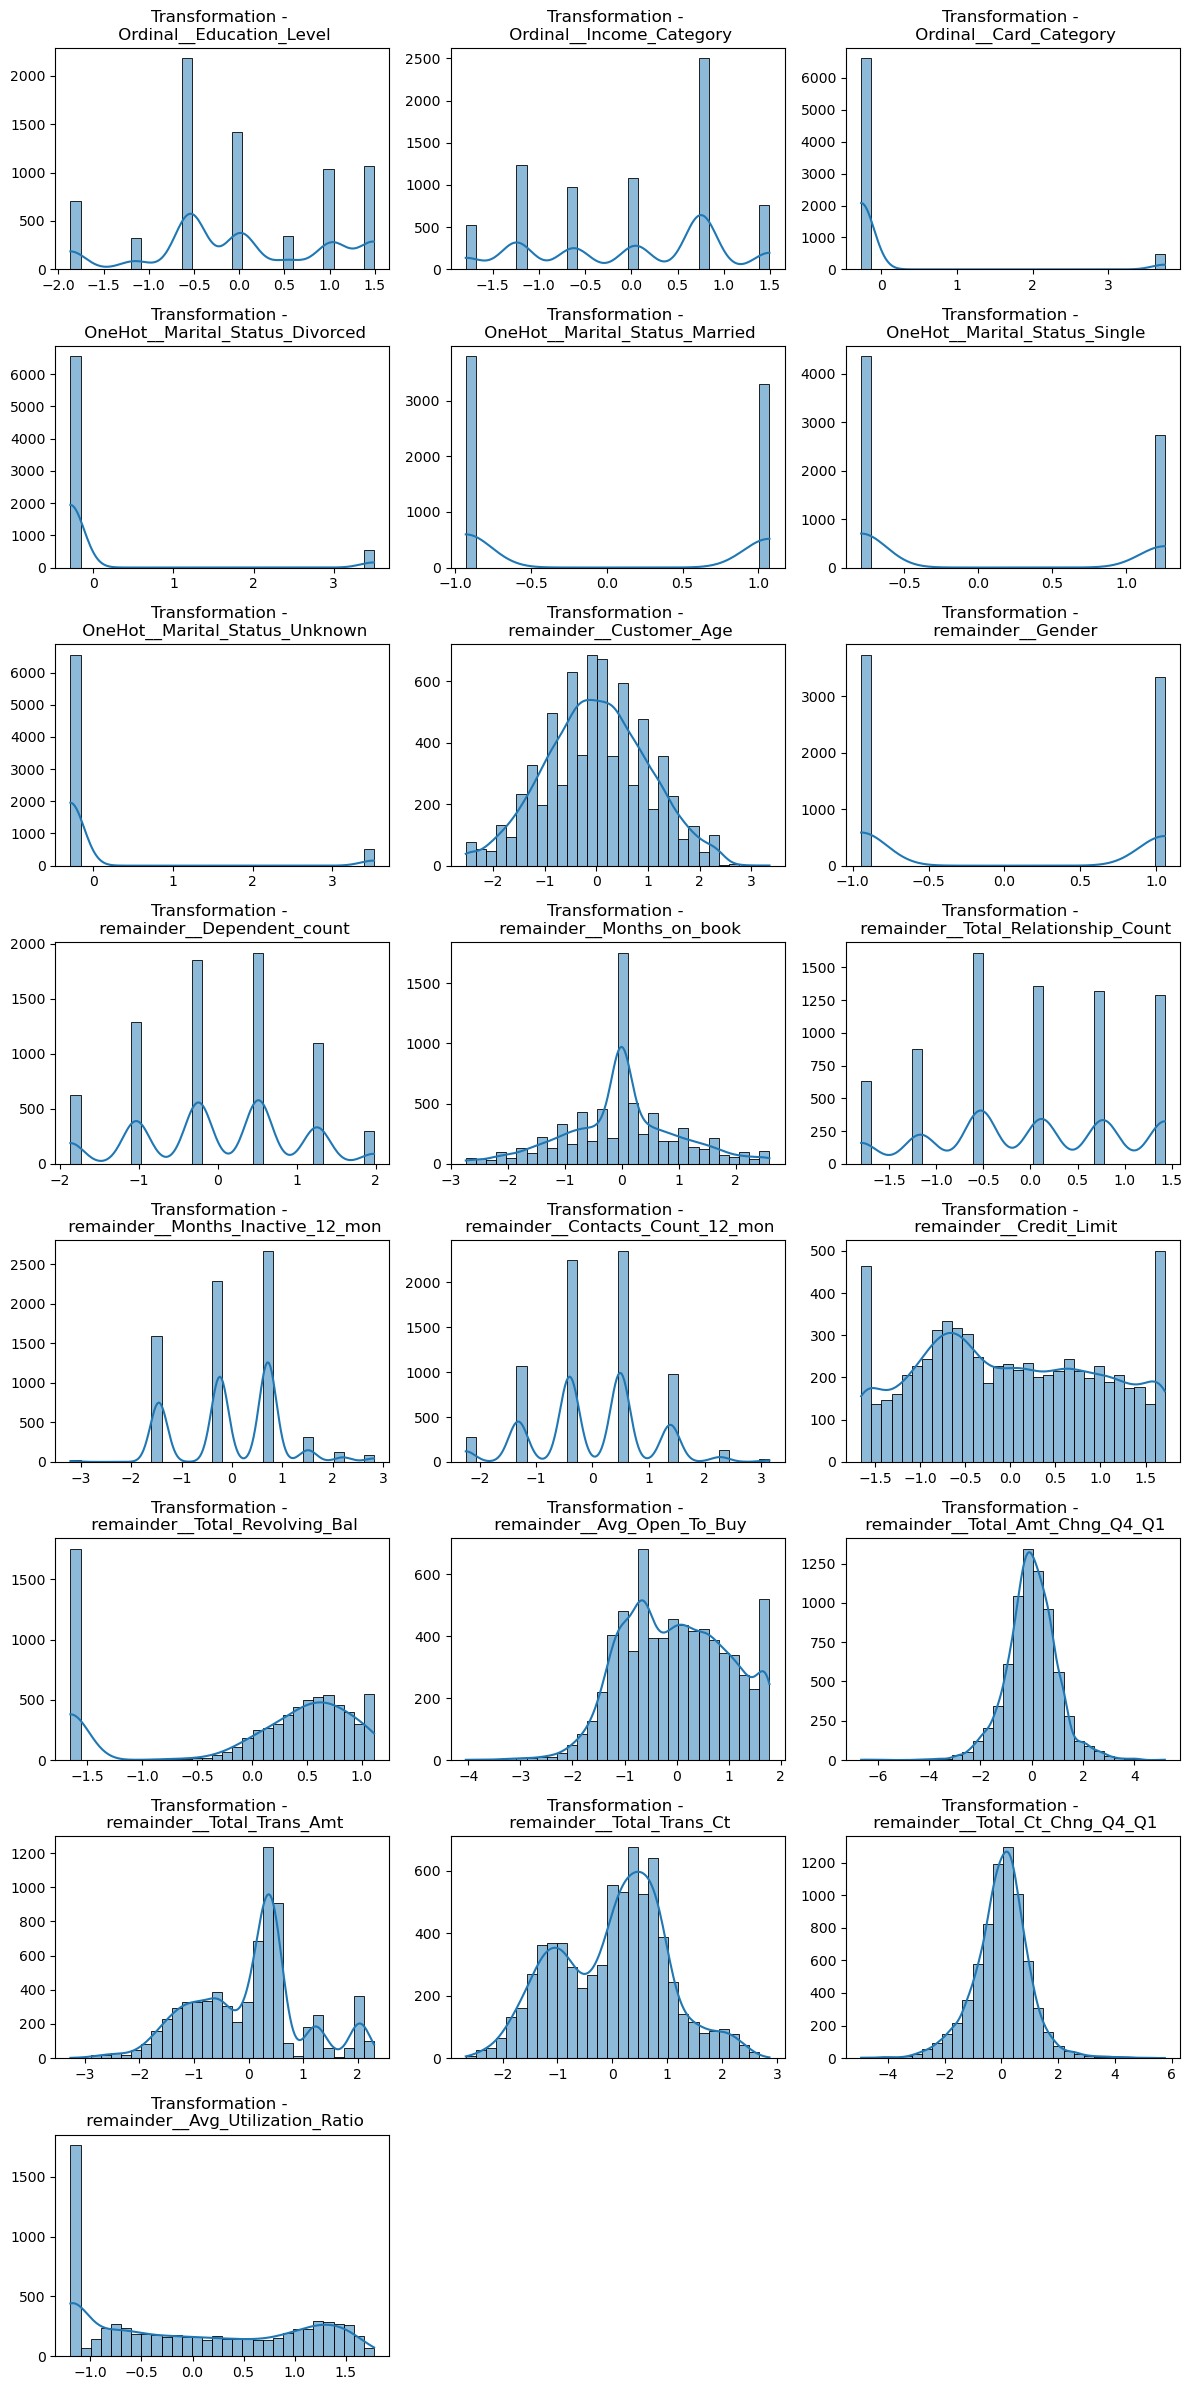

In [36]:
plot_all_histograms(X_train_transformed_df, title_prefix= "Transformation - \n")

**Classification Algorithm**

In [37]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

In [38]:
models = {
    "AdaBoost Classifier": AdaBoostClassifier(),
    "Gradient Boosting Classifier": GradientBoostingClassifier(),
    "XGBoosting Classifier": XGBClassifier(),
    "LightGBM Classifier": LGBMClassifier(),
}

In [39]:
for i in range(len(list(models))):
    model = list(models.values())[i]
    model.fit(X_train_transformed, y_train)

    y_test_pred = model.predict(X_test_transformed)

    print(list(models.keys())[i])
    print("-----------------------------------")
    print("Model performance for Test Set")
    print("Accuracy Score:", accuracy_score(y_test, y_test_pred))
    print("Classification Report: \n", classification_report(y_test, y_test_pred))
    print("Confusion Matrix: \n", confusion_matrix(y_test, y_test_pred))
    print("-----------------------------------")
    print("\n")

AdaBoost Classifier
-----------------------------------
Model performance for Test Set
Accuracy Score: 0.9447186574531096
Classification Report: 
               precision    recall  f1-score   support

           0       0.95      0.98      0.97      2550
           1       0.90      0.74      0.81       489

    accuracy                           0.94      3039
   macro avg       0.93      0.86      0.89      3039
weighted avg       0.94      0.94      0.94      3039

Confusion Matrix: 
 [[2510   40]
 [ 128  361]]
-----------------------------------


Gradient Boosting Classifier
-----------------------------------
Model performance for Test Set
Accuracy Score: 0.9684106614017769
Classification Report: 
               precision    recall  f1-score   support

           0       0.98      0.99      0.98      2550
           1       0.93      0.87      0.90       489

    accuracy                           0.97      3039
   macro avg       0.95      0.93      0.94      3039
weighted avg 

In [45]:
#Hyperparameter Tuning

In [46]:
xgboost_params = {
    "n_estimators": [100,200,300,500],
    "learning_rate": [0.01, 0.1],
    "max_depth" : [5,8,12,20,30],
    "colsample_bytree" : [0.3, 0.4, 0.5, 0.8, 1],
}

In [47]:
from sklearn.model_selection import RandomizedSearchCV

In [48]:
xgboost_model = XGBClassifier()
random_search = RandomizedSearchCV(estimator= XGBClassifier(), param_distributions= xgboost_params, scoring= "accuracy", cv= 5, n_jobs= -1)
random_search.fit(X_train_transformed, y_train)

,estimator,"XGBClassifier...ree=None, ...)"
,param_distributions,"{'colsample_bytree': [0.3, 0.4, ...], 'learning_rate': [0.01, 0.1], 'max_depth': [5, 8, ...], 'n_estimators': [100, 200, ...]}"
,n_iter,10
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,None
,error_score,nan


In [49]:
print("Best Params:", random_search.best_params_)
y_pred = random_search.predict(X_test_transformed)
print("Model performance for Test Set")
print("Accuracy Score:", accuracy_score(y_test, y_pred))
print("Classification Report: \n", classification_report(y_test, y_pred))
print("Confusion Matrix: \n", confusion_matrix(y_test, y_pred))

Best Params: {'n_estimators': 200, 'max_depth': 20, 'learning_rate': 0.1, 'colsample_bytree': 0.5}
Model performance for Test Set
Accuracy Score: 0.9730174399473511
Classification Report: 
               precision    recall  f1-score   support

           0       0.98      0.99      0.98      2550
           1       0.93      0.90      0.91       489

    accuracy                           0.97      3039
   macro avg       0.96      0.94      0.95      3039
weighted avg       0.97      0.97      0.97      3039

Confusion Matrix: 
 [[2517   33]
 [  49  440]]
